## Import Library yang digunakan

In [1]:
import pandas as pd    
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import time

from scipy.special import beta as beta_func
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import fisk, burr, kstest, anderson, chisquare

## Load dan Persiapan Data

Pada bagian ini dilakukan proses pembacaan data harga saham serta tahap awal pembersihan data sebelum dilakukan analisis lebih lanjut.

In [2]:
# Load data dan print data sebelum cleaning
df_saham = pd.read_csv("lq45_mar26_close.csv", index_col="Date", parse_dates=True)
df_saham.columns = df_saham.columns.str.replace('.JK', '', regex=False)
print(df_saham.head())

            AADI  ADMR        ADRO        AKRA  AMMN        AMRT        ANTM  \
Date                                                                           
2017-01-02   NaN   NaN  422.978363  744.446777   NaN  569.011597  721.587830   
2017-01-03   NaN   NaN  434.207947  722.733643   NaN  564.459595  713.525452   
2017-01-04   NaN   NaN  424.226166  735.141174   NaN  528.042847  697.400513   
2017-01-05   NaN   NaN  415.492004  725.835632   NaN  528.042847  701.431763   
2017-01-06   NaN   NaN  422.978363  732.039124   NaN  537.147095  697.400513   

                   ASII         BBCA         BBNI  ...  NCKL         PGAS  \
Date                                               ...                      
2017-01-02  5174.229492  2480.385498  1858.162354  ...   NaN  1641.824463   
2017-01-03  5127.333496  2524.392090  1841.346436  ...   NaN  1714.794067   
2017-01-04  5002.276855  2512.390381  1883.386475  ...   NaN  1745.198486   
2017-01-05  5080.437012  2508.389893  1891.794434  ...

### Menentukan Periode Data yang Konsisten

Setiap saham memiliki tanggal awal pencatatan yang berbeda. Oleh karena itu, dilakukan pencarian tanggal pertama yang valid untuk seluruh saham.

Tujuannya adalah agar analisis hanya menggunakan periode waktu di mana semua saham memiliki data lengkap.

In [3]:
# Cari saham yang paling baryu
all_first_dates = df_saham.apply(lambda col: col.first_valid_index())
first_valid_date = all_first_dates.max()
saham_terbaru = all_first_dates.idxmax()

print(saham_terbaru)
print(first_valid_date)

AADI
2024-12-05 00:00:00


### Pembersihan Data

Dataset disesuaikan agar hanya mencakup periode waktu yang sama untuk seluruh saham.

Langkah yang dilakukan:
- Memotong data berdasarkan tanggal awal bersama
- Menghapus nilai yang mengandung missing value (NaN)

Hal ini penting untuk menjaga konsistensi dalam perhitungan return dan kovarian.

In [4]:
# Slice semua data
df_saham = df_saham.loc[first_valid_date:]

# Hapus NaN
df_saham = df_saham.dropna(axis=0, how='any')

print(f'Shape data: {df_saham.shape}')
print(f'NaN: {df_saham.isna().sum().sum()}')
print(f'Range dataset: {df_saham.index.min()} s/d {df_saham.index.max()}')

# Print data setelah cleaning
print(df_saham.head())

Shape data: (306, 45)
NaN: 0
Range dataset: 2024-12-05 00:00:00 s/d 2026-03-30 00:00:00
                   AADI         ADMR         ADRO         AKRA    AMMN  \
Date                                                                     
2024-12-05  6241.059082  1258.115356  1911.487671  1215.968994  9550.0   
2024-12-06  7484.578125  1253.349731  1878.812622  1220.592529  9525.0   
2024-12-09  8962.723633  1281.943237  2189.225098  1243.709595  9325.0   
2024-12-10  9643.139648  1258.115356  2230.068848  1252.956665  9375.0   
2024-12-11  9009.649414  1239.052979  2132.043945  1234.462769  9225.0   

                   AMRT         ANTM         ASII         BBCA         BBNI  \
Date                                                                          
2024-12-05  2951.072998  1419.330811  4788.159180  9464.409180  4071.646729   
2024-12-06  3030.031494  1414.567993  4742.119141  9302.821289  4105.436523   
2024-12-09  2901.723877  1419.330811  4811.178711  9556.745117  4223.699707  

### Visualisasi Harga Saham

Dilakukan visualisasi harga penutupan masing-masing saham dalam bentuk grafik time series.

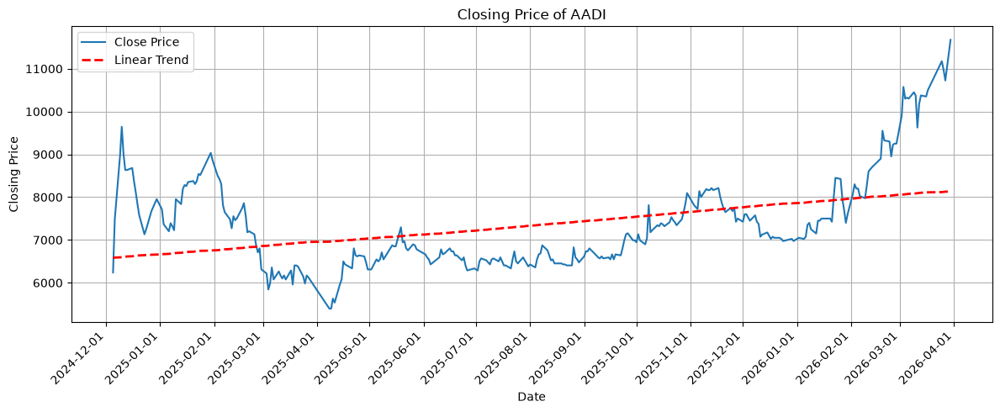

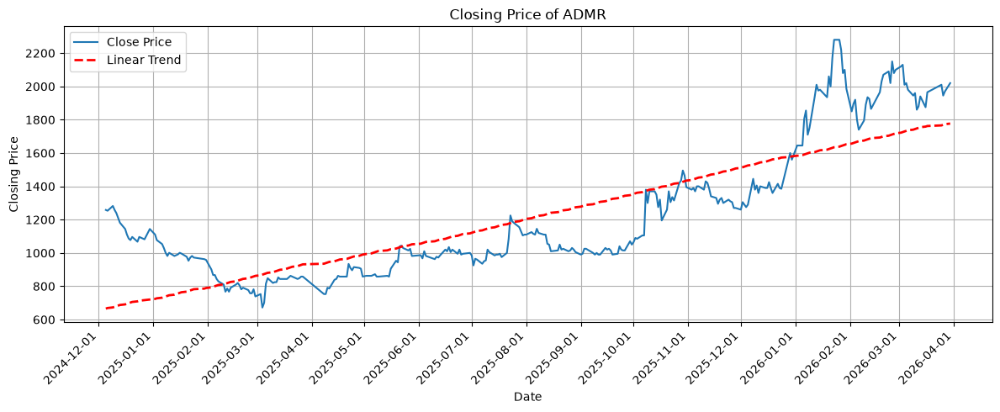

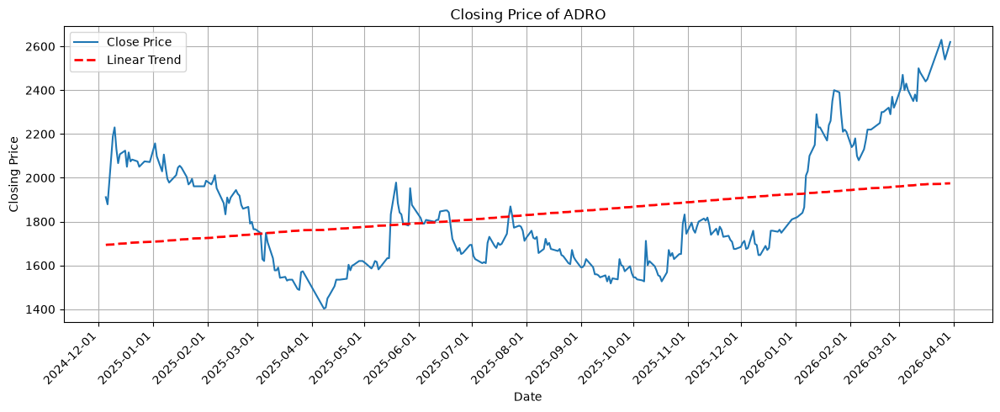

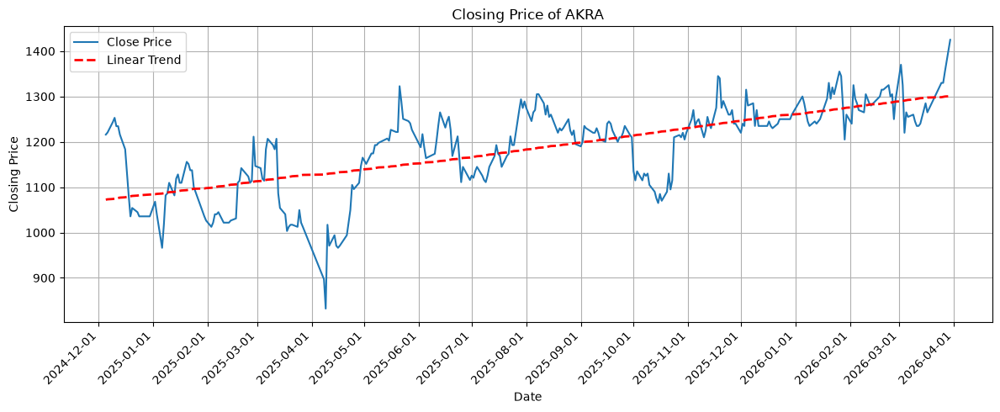

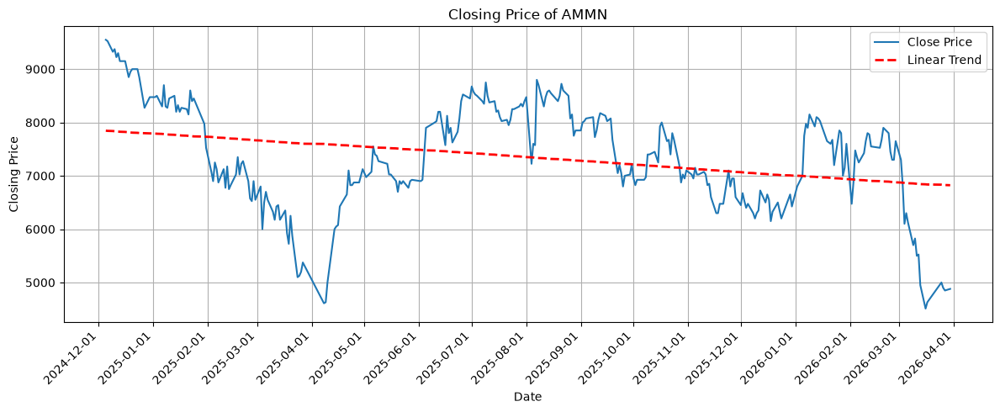

...

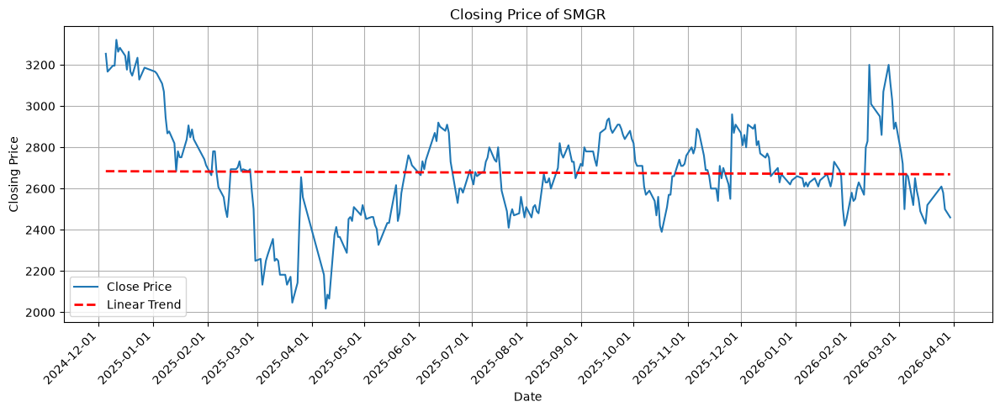

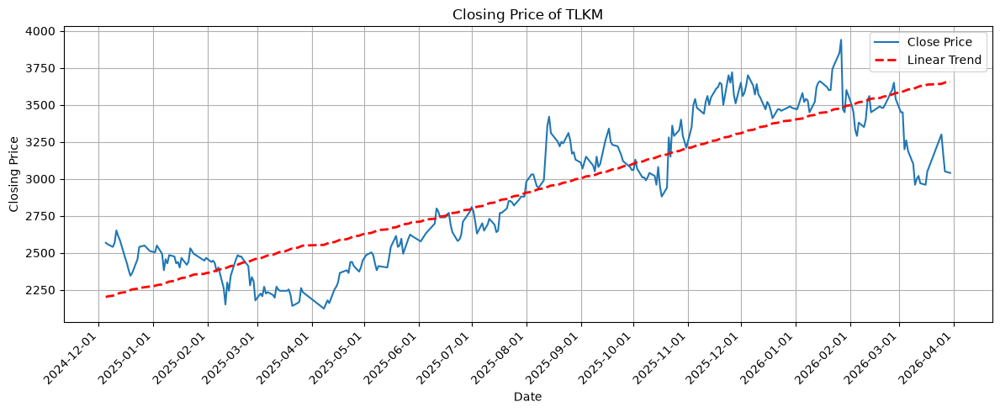

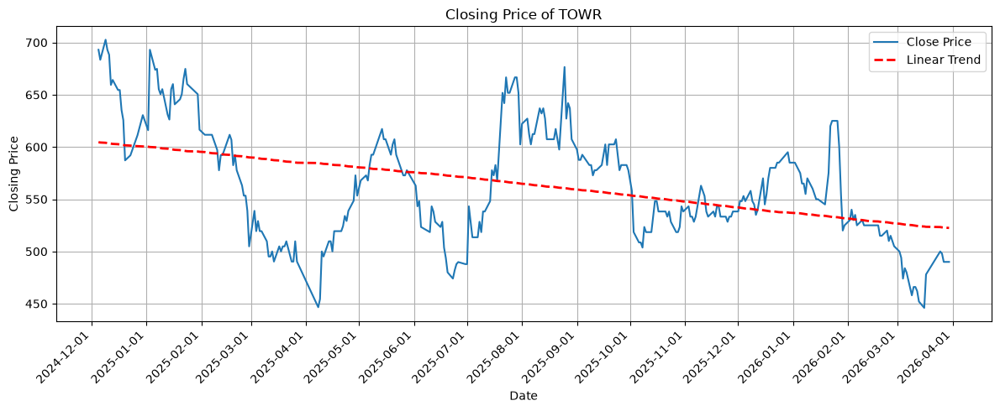

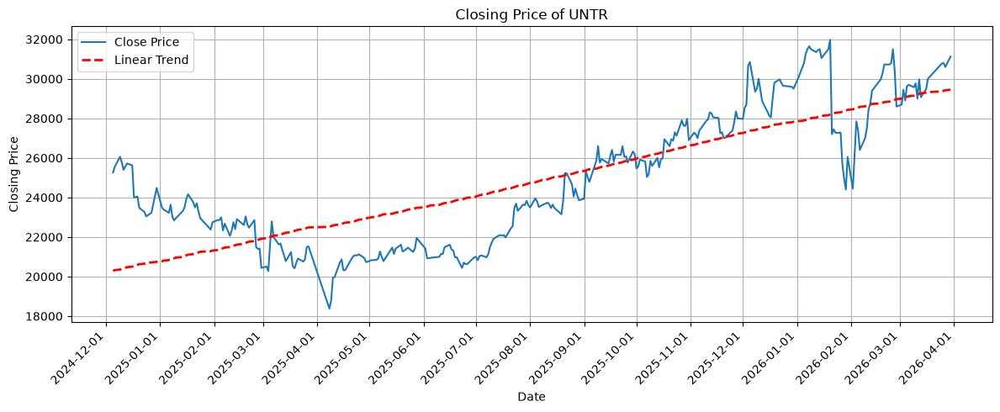

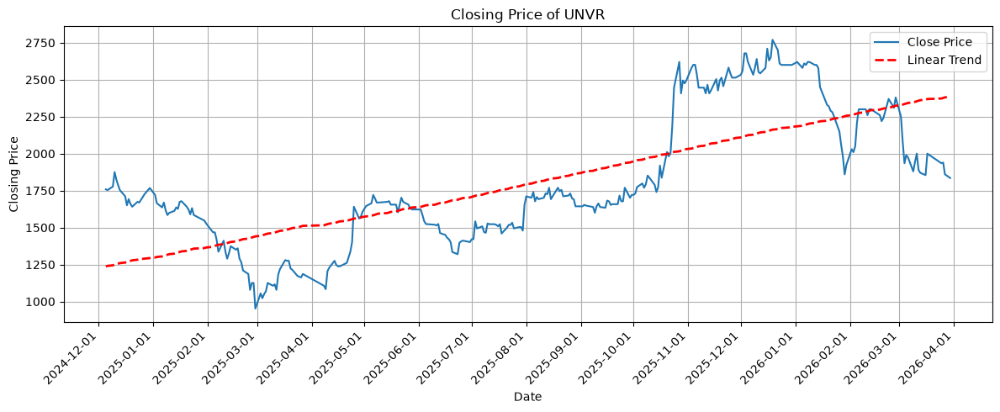

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

for stock_code in df_saham.columns:

    # Create a new figure for each stock
    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot closing price
    ax.plot(
        df_saham.index,
        df_saham[stock_code],
        label="Close Price",
        linewidth=1.5
    )

    # Compute and plot the linear trend line
    x = np.arange(len(df_saham))
    y = df_saham[stock_code].values

    slope, intercept = np.polyfit(x, y, 1)
    trend_line = slope * x + intercept

    ax.plot(
        df_saham.index,
        trend_line,
        linestyle="--",
        color="red",
        linewidth=2,
        label="Linear Trend"
    )

    # Customize plot appearance
    ax.set_title(f"Closing Price of {stock_code}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Closing Price")

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

### Perhitungan Log Return

Return saham dihitung menggunakan metode log return, yaitu:

$r_t = \ln \left(\frac{P_t}{P_{t-1}}\right)$.

Nilai NaN yang muncul akibat pergeseran data kemudian dihapus.

In [6]:
# Hitung log return
log_returns = np.log(df_saham / df_saham.shift(1))
print(log_returns)

log_returns.dropna().reset_index().to_csv("lq45_log_returns.csv", index=False)



                AADI      ADMR      ADRO      AKRA      AMMN      AMRT  \
Date                                                                     
2024-12-05       NaN       NaN       NaN       NaN       NaN       NaN   
2024-12-06  0.181695 -0.003795 -0.017242  0.003795 -0.002621  0.026404   
2024-12-09  0.180230  0.022557  0.152908  0.018762 -0.021221 -0.043268   
2024-12-10  0.073173 -0.018762  0.018485  0.007408  0.005348  0.036732   
2024-12-11 -0.067951 -0.015267 -0.044951 -0.014870 -0.016129 -0.026580   
...              ...       ...       ...       ...       ...       ...   
2026-03-17  0.014389  0.046884  0.004090 -0.015687  0.026260  0.017452   
2026-03-25  0.062304  0.022642  0.070896  0.050107  0.076881  0.053885   
2026-03-26 -0.018059 -0.032873 -0.019194  0.000000 -0.020203 -0.043558   
2026-03-27 -0.023042  0.012772 -0.015625  0.018623 -0.010257 -0.003431   
2026-03-30  0.084872  0.025064  0.031010  0.050370  0.006167 -0.034969   

                ANTM      ASII      B

In [ ]:
df_tlkm = pd.DataFrame({
    'Close': df_saham['TLKM'],
    'Return': log_returns['TLKM']
}).dropna()

df_tlkm['Return'] = df_tlkm['Return'].round(5)
df_tlkm.index = df_tlkm.index.strftime('%Y-%m-%d')
df_tlkm.index.name = 'Tanggal'

print(df_tlkm.to_string())
df_tlkm.to_csv("tabel41.csv", index=True)

                  Close   Return
Tanggal                         
2024-12-06  2558.485352 -0.00362
2024-12-09  2539.945557 -0.00727
2024-12-10  2567.755371  0.01089
2024-12-11  2651.184082  0.03197
2024-12-12  2614.104736 -0.01408
2024-12-13  2586.294922 -0.01070
2024-12-16  2465.786621 -0.04772
2024-12-17  2428.707275 -0.01515
2024-12-18  2382.357910 -0.01927
2024-12-19  2345.278320 -0.01569
2024-12-20  2363.818115  0.00787
2024-12-23  2456.516846  0.03847
2024-12-24  2539.945557  0.03340
2024-12-27  2549.215576  0.00364
2024-12-30  2512.135986 -0.01465
2025-01-02  2502.866211 -0.00370
2025-01-03  2549.215576  0.01835
2025-01-06  2493.596191 -0.02206
2025-01-07  2382.357910 -0.04564
2025-01-08  2456.516846  0.03065
2025-01-09  2428.707275 -0.01139
2025-01-10  2484.326416  0.02264
2025-01-13  2475.056641 -0.00374
2025-01-14  2428.707275 -0.01890
2025-01-15  2437.977051  0.00381
2025-01-16  2400.897461 -0.01533
2025-01-17  2465.786621  0.02667
2025-01-20  2419.437256 -0.01898
2025-01-21

### Visualisasi Log Return

Setiap saham divisualisasikan dalam bentuk grafik log return.

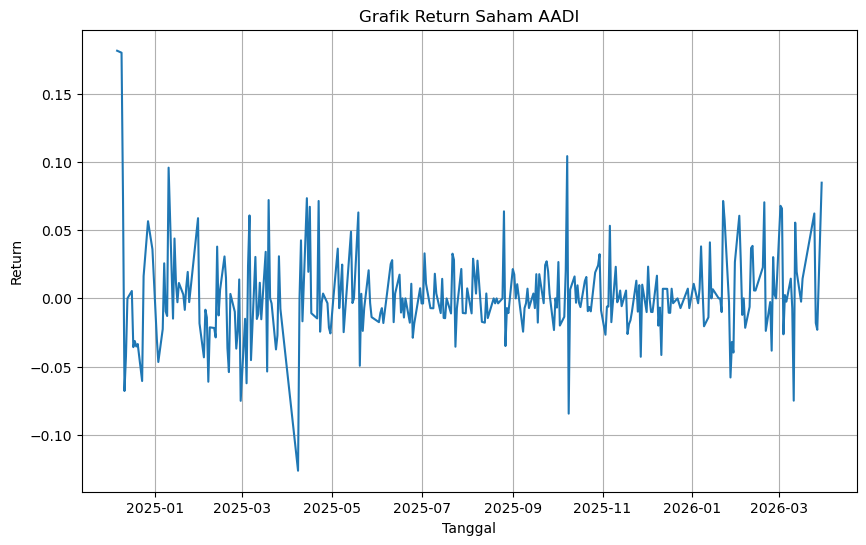

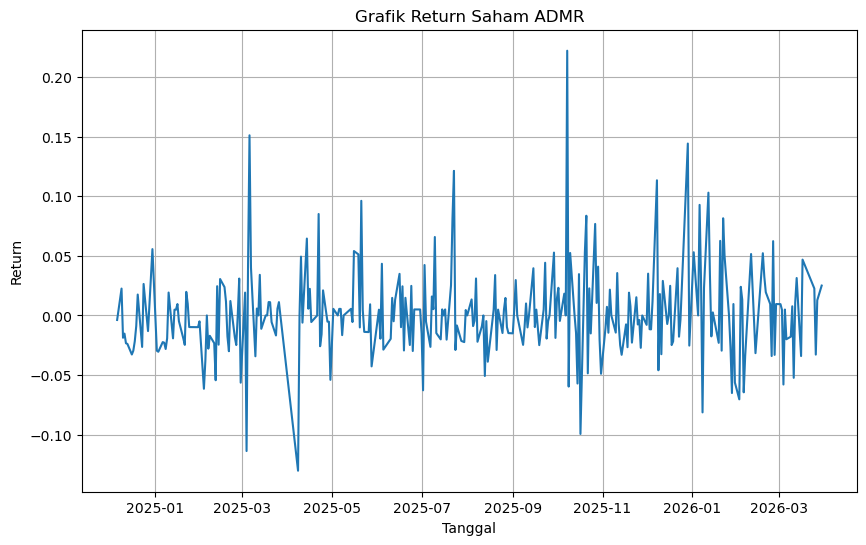

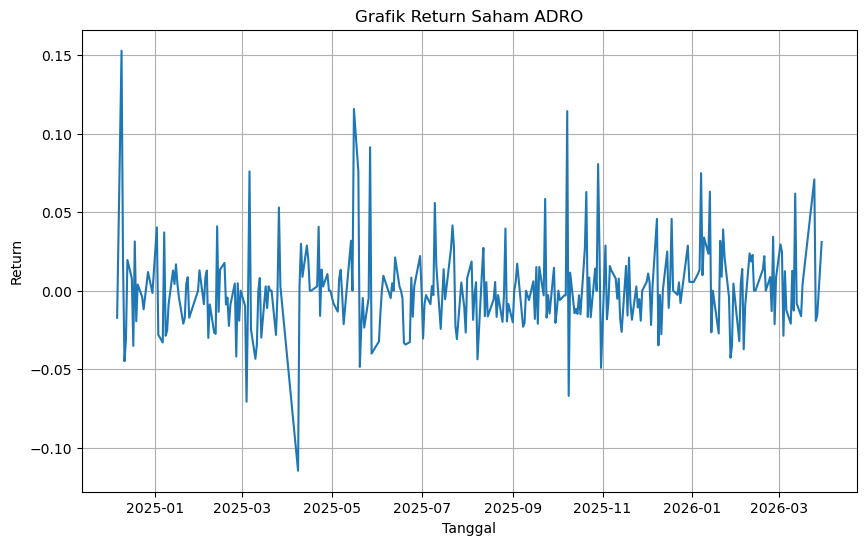

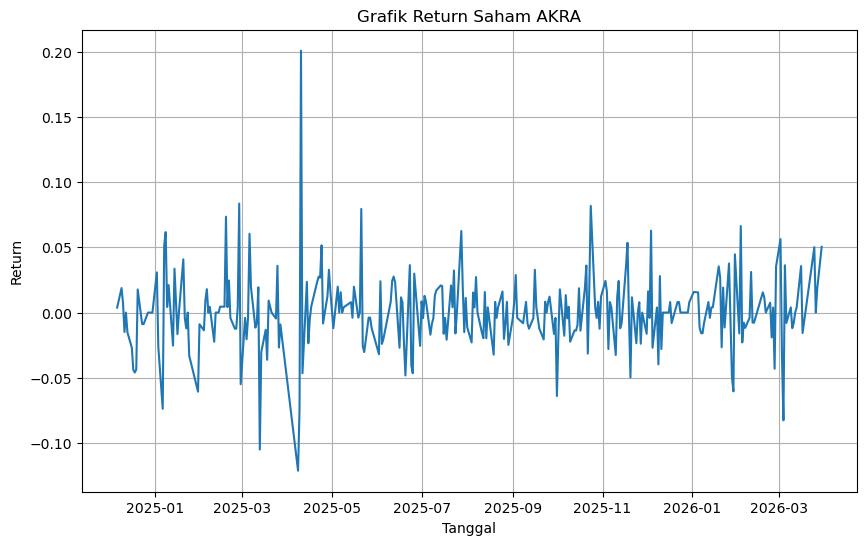

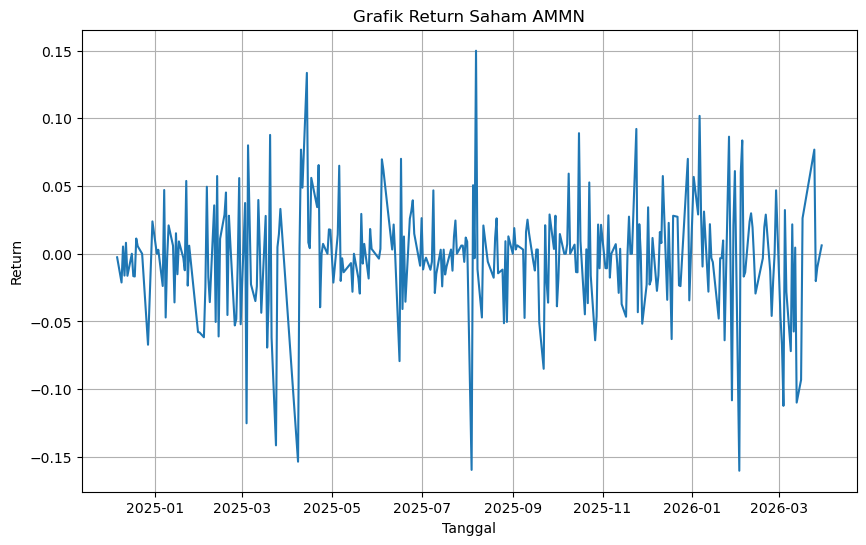

...

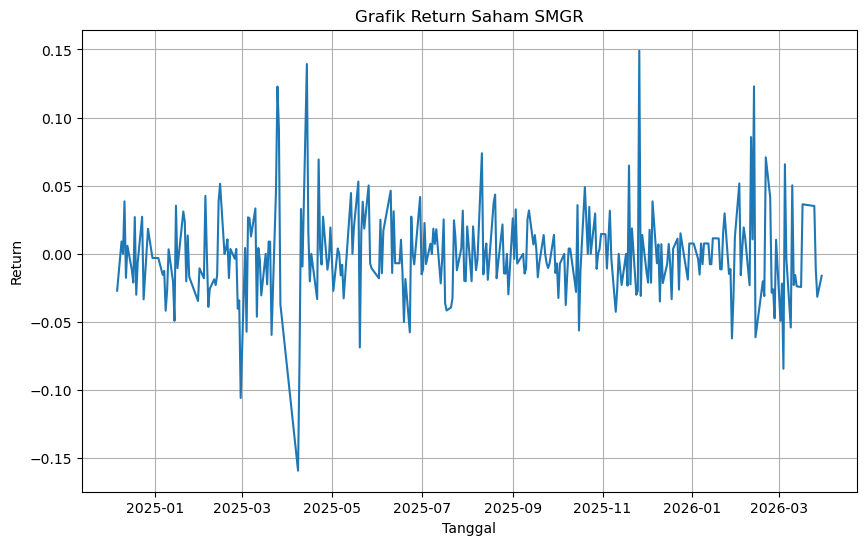

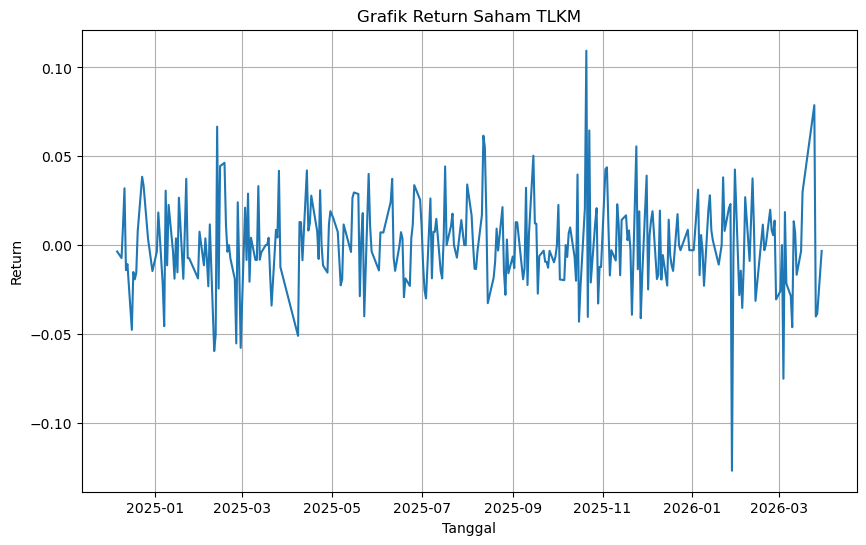

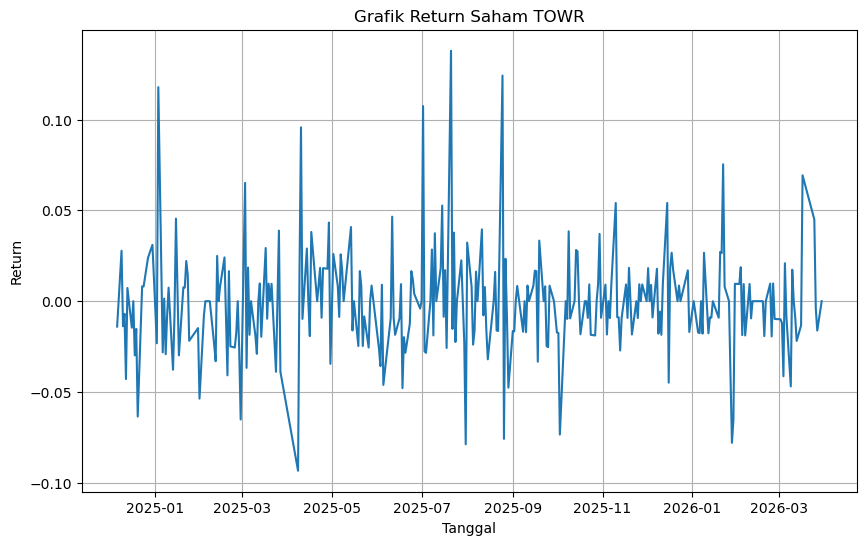

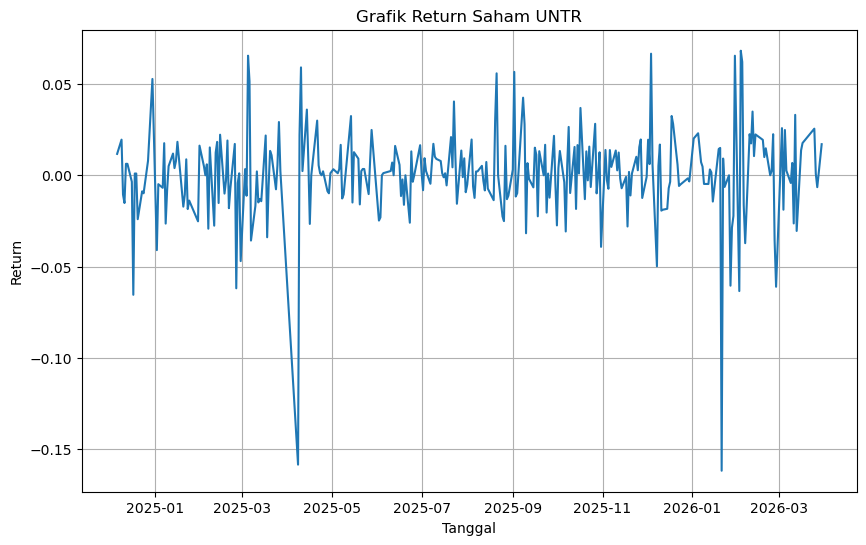

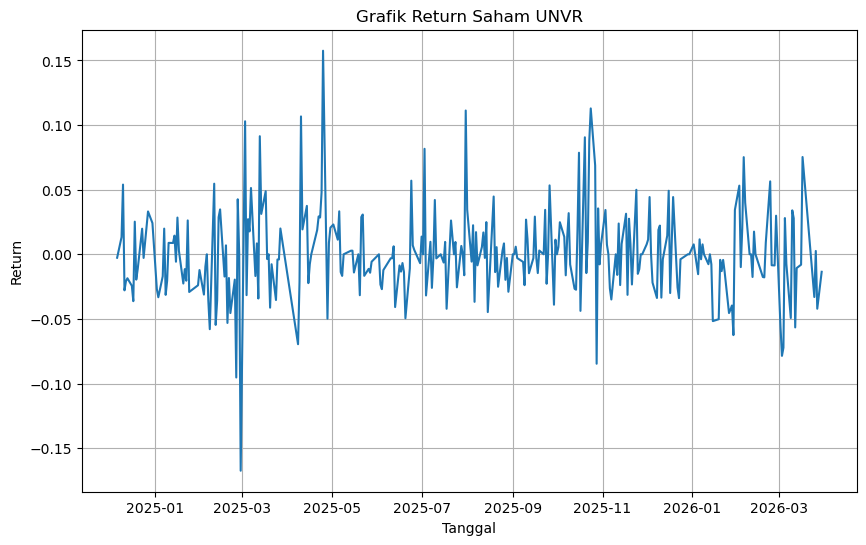

In [7]:
for column in log_returns.columns:
    plt.figure(figsize=(10, 6))
    
    plt.plot(log_returns.index, log_returns[column])
    plt.title(f'Grafik Return Saham {column}')
    plt.xlabel('Tanggal')
    plt.ylabel('Return')
    plt.grid(True)
    plt.show()

### Statistik Deskriptif Log Return

Dilakukan analisis statistik deskriptif terhadap log return, meliputi:
- mean
- standar deviasi
- nilai minimum dan maksimum

Analisis ini memberikan gambaran awal karakteristik distribusi return masing-masing saham.

In [36]:
log_returns_desc = log_returns.describe().T

log_returns_desc['variance'] = log_returns.var()
log_returns_desc['skewness'] = log_returns.skew()
log_returns_desc['median'] = log_returns.median()
log_returns_desc['mode'] = log_returns.mode().iloc[0]

print(log_returns_desc)

log_returns_desc.to_csv("tabel42_log_returns_descriptive_stats.csv")


      count      mean       std       min       25%       50%       75%  \
AADI  305.0  0.002053  0.033069 -0.126441 -0.014337 -0.002837  0.016314   
ADMR  305.0  0.001552  0.037866 -0.130362 -0.020101  0.000000  0.018265   
ADRO  305.0  0.001034  0.027882 -0.114739 -0.016261  0.000000  0.012685   
AKRA  305.0  0.000520  0.029397 -0.121214 -0.013668  0.000000  0.015504   
AMMN  305.0 -0.002201  0.041816 -0.160200 -0.021221  0.000000  0.020928   
AMRT  305.0 -0.002433  0.028113 -0.093434 -0.017938 -0.003431  0.012685   
ANTM  305.0  0.002959  0.035422 -0.155171 -0.016475  0.003221  0.023690   
ASII  305.0  0.000926  0.022714 -0.097374 -0.011385  0.000000  0.011929   
BBCA  305.0 -0.001257  0.017939 -0.089153 -0.011940 -0.002684  0.008253   
BBNI  305.0 -0.000184  0.022371 -0.079022 -0.012210 -0.002318  0.008265   
BBRI  305.0 -0.000365  0.021892 -0.106733 -0.012121 -0.002378  0.009346   
BBTN  305.0  0.000345  0.027371 -0.102760 -0.013730 -0.003914  0.011742   
BMRI  305.0 -0.000502  0.

### Distribusi Return Saham

Histogram log return ditampilkan untuk setiap saham.

Dua jenis histogram digunakan:
- density (probability density)
- frekuensi (count)

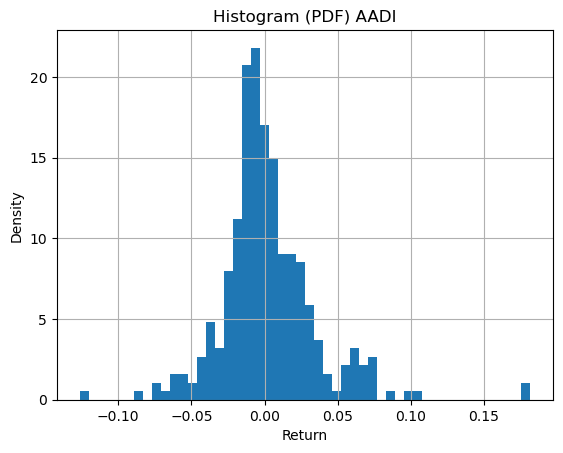

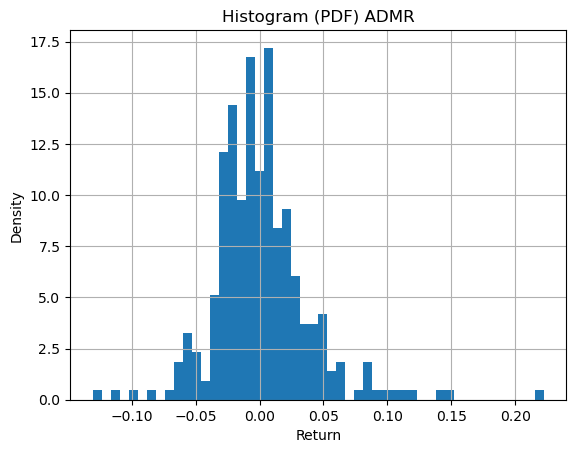

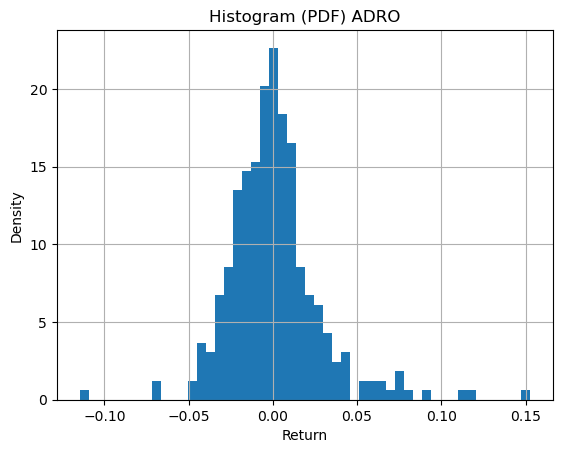

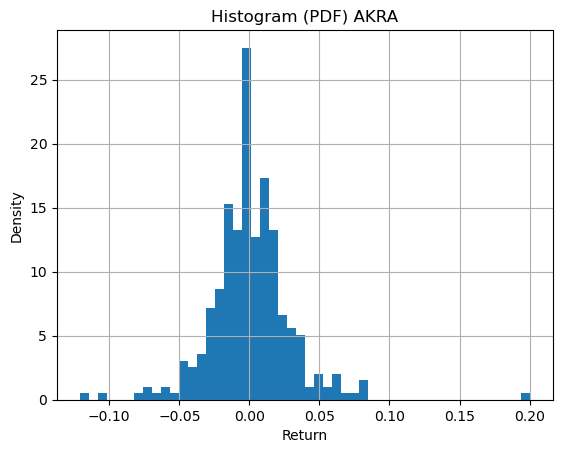

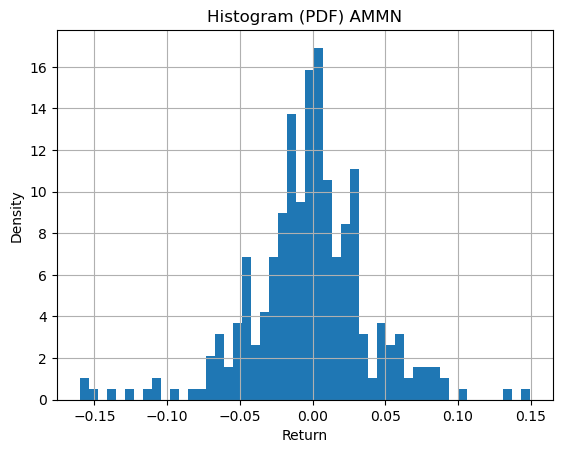

...

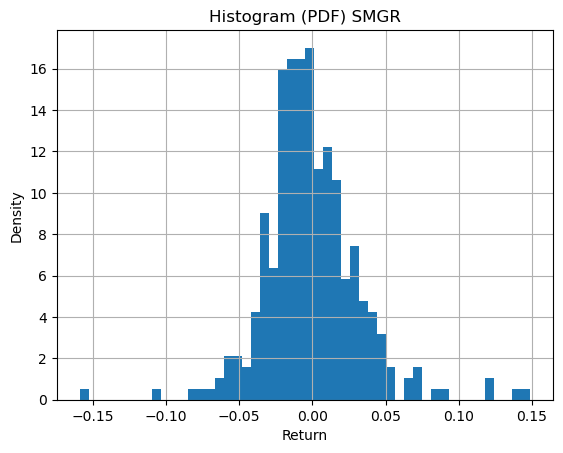

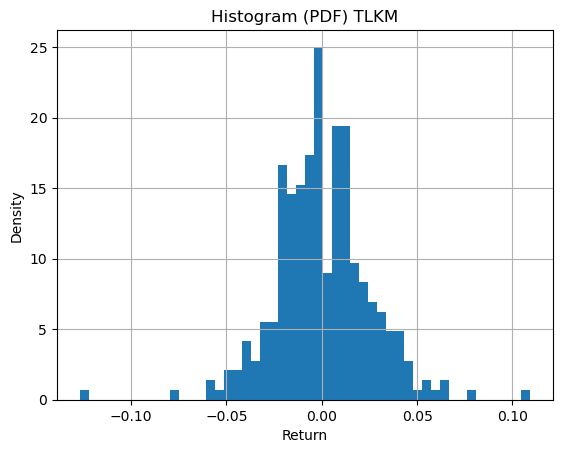

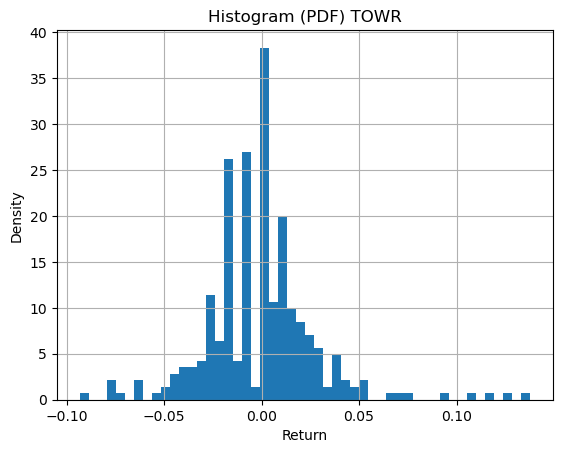

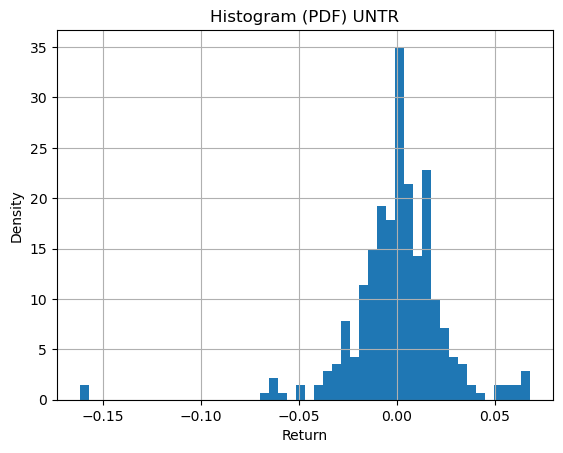

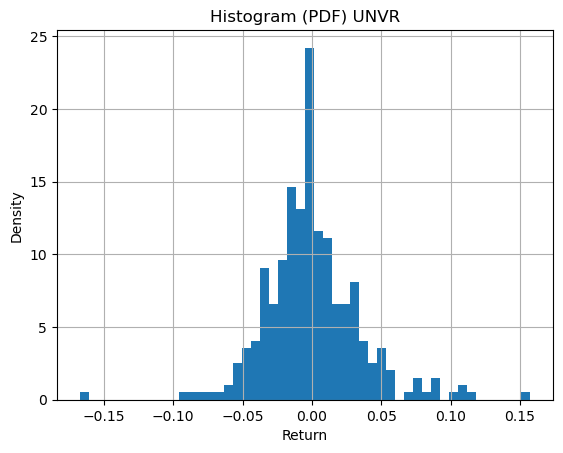

In [9]:
for col in log_returns.columns:
    plt.figure()
    log_returns[col].hist(bins=50, density=True) 
    plt.title(f'Histogram (PDF) {col}')
    plt.xlabel('Return')
    plt.ylabel('Density')
    plt.show()

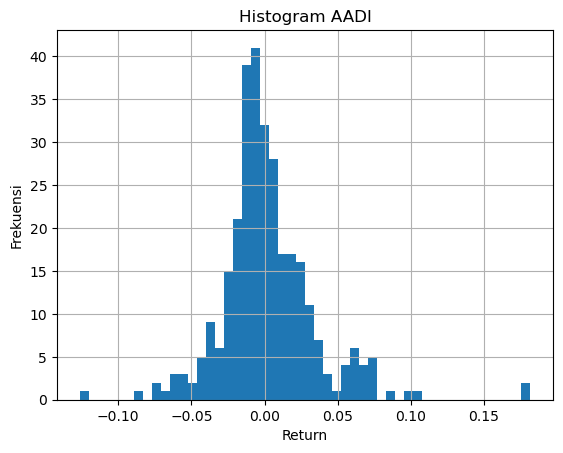

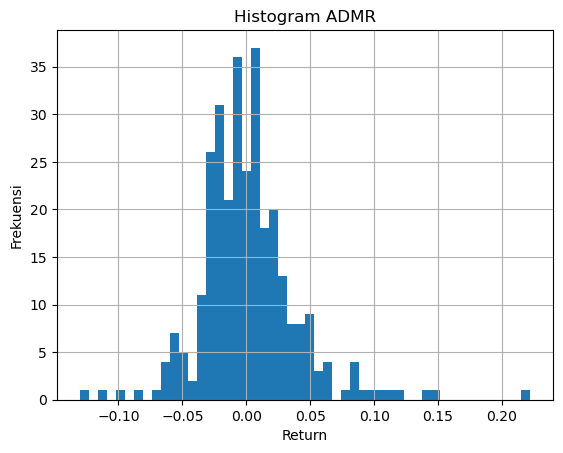

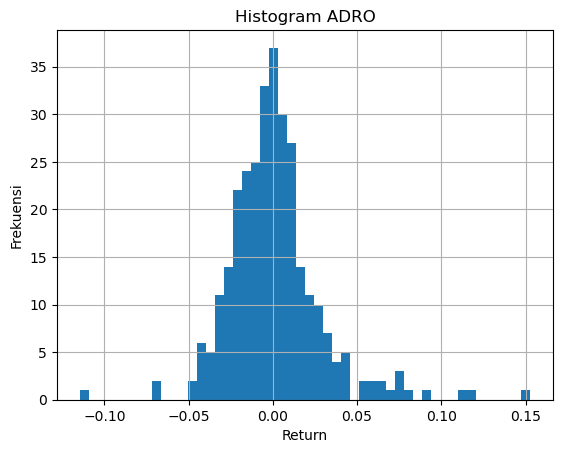

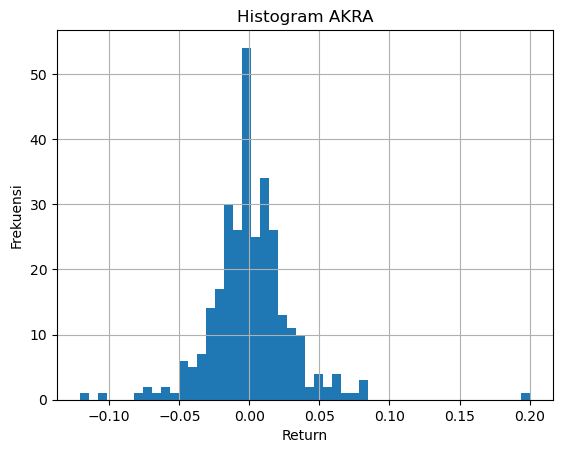

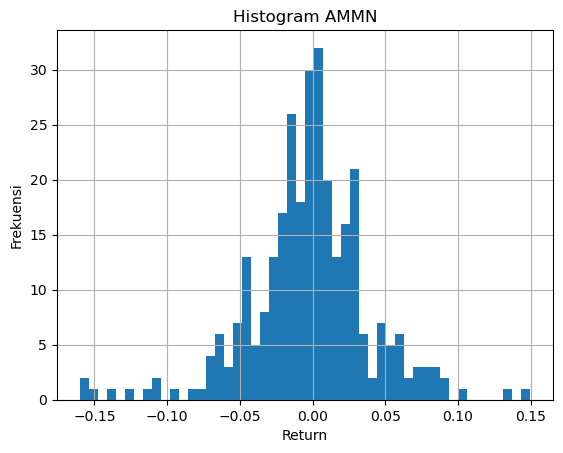

...

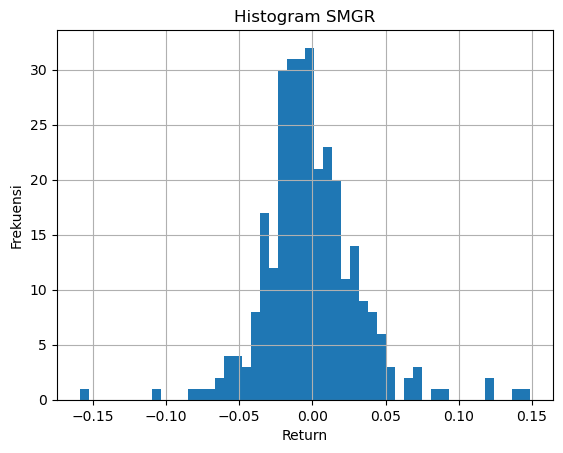

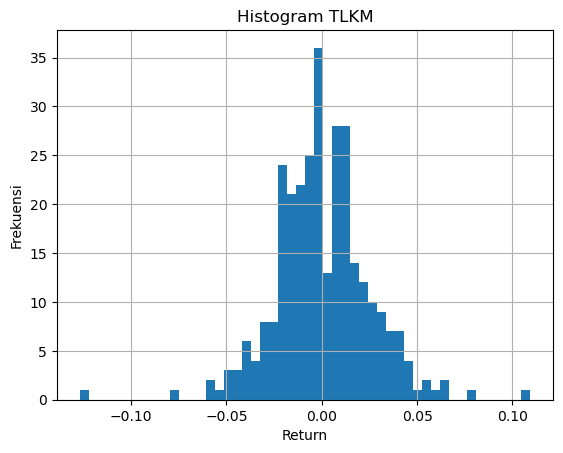

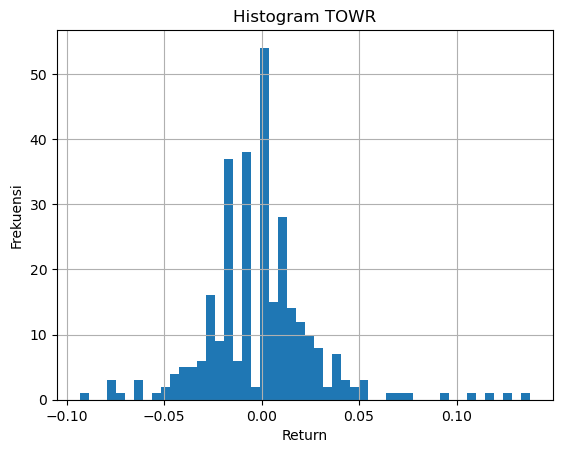

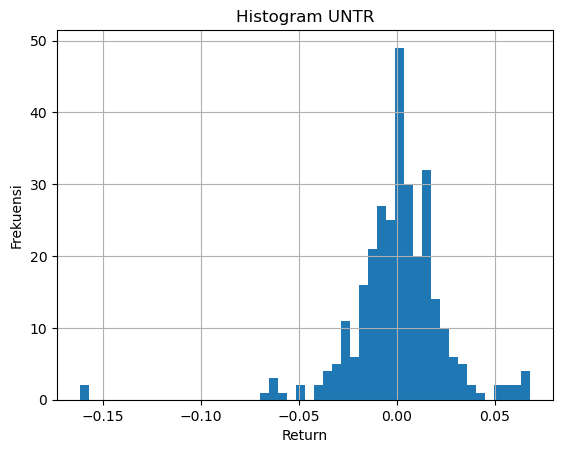

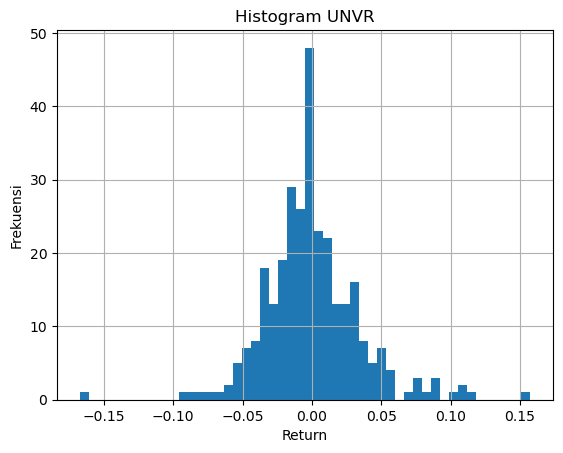

In [10]:
for col in log_returns.columns:
    plt.figure()
    log_returns[col].hist(bins=50) 
    plt.title(f'Histogram {col}')
    plt.xlabel('Return')
    plt.ylabel('Frekuensi')
    plt.show()

## Estimasi Parameter Distribusi

Setelah distribusi return diidentifikasi melalui histogram, dilakukan estimasi parameter menggunakan metode **Maximum Likelihood Estimation (MLE)**.

Secara umum:

$L(\theta|x) = \prod_{i=1}^{n} f(x_i|\theta), \quad 
\ln L(\theta|x) = \sum_{i=1}^{n} \ln f(x_i|\theta)$

Contoh:

**Log-Logistik:**

$\ln L = \sum \left[ \ln \left(\frac{\alpha}{\beta}\right) + (\alpha-1)\ln \left(\frac{x_i-\gamma}{\beta}\right) - 2\ln \left(1+\left(\frac{x_i-\gamma}{\beta}\right)^\alpha\right) \right]$

**Burr (4P):**

$\ln L = \sum \left[ \ln \left(\frac{\alpha k}{\beta}\right) + (\alpha-1)\ln \left(\frac{x_i-\gamma}{\beta}\right) + (1-k)\ln \left(1+\left(\frac{x_i-\gamma}{\beta}\right)^\alpha\right) \right]$

Parameter diperoleh dengan menyelesaikan:

$\frac{\partial \ln L}{\partial \theta} = 0$

Karena tidak memiliki solusi analitik, estimasi dilakukan menggunakan software **EasyFit**.

In [11]:
df_param = pd.read_csv("nilai_parameter.csv")
print(df_param)

    No Saham         Model        k         alpha          beta         gamma
0    1  AADI     Burr (4P)  0.56587  1.027900e+02  1.279800e+00 -1.291700e+00
1    2  ADMR     Burr (4P)  0.57559  9.049300e+01  1.323200e+00 -1.337400e+00
2    3  ADRO  Log-Logistic      NaN  1.530500e+01  2.098300e-01 -2.110700e-01
3    4  AKRA     Burr (4P)  0.79324  3.199900e+02  4.263400e+00 -4.268000e+00
4    5  AMMN  Log-Logistic      NaN  2.040000e+08  4.450000e+06 -4.450000e+06
5    6  AMRT  Log-Logistic      NaN  5.143800e+01  7.813800e-01 -7.843700e-01
6    7  ANTM  Log-Logistic      NaN  7.850000e+06  1.510000e+05 -1.510000e+05
7    8  ASII     Burr (4P)  0.75371  1.020000e+08  1.040000e+06 -1.040000e+06
8    9  BBCA     Burr (4P)  0.75580  1.090000e+06  9.442700e+03 -9.442700e+03
9   10  BBNI     Burr (4P)  0.57290  2.943800e+04  2.682800e+02 -2.682900e+02
10  11  BBRI     Burr (4P)  0.65518  1.220000e+06  1.135800e+04 -1.135800e+04
11  12  BBTN     Burr (4P)  0.51255  1.740000e+07  1.790000e+05 

## Uji Kesesuaian Distribusi

Model distribusi yang diperoleh kemudian diuji menggunakan:
- Kolmogorov-Smirnov (KS)
- Anderson-Darling (AD)
- Chi-Square (CS)

Hipotesis:

$H_0$: data mengikuti distribusi  
$H_1$: data tidak mengikuti distribusi  

Kriteria:

$A_{hitung} < A_{tabel} \Rightarrow H_0$ diterima  

Distribusi dianggap sesuai jika semua uji memenuhi kriteria.

Hasil estimasi parameter dan uji distribusi selanjutnya disajikan pada tabel berikut.

In [12]:
df_uji = pd.read_csv("asumsi_model.csv")
print(df_uji)

    Saham      Uji Distribusi Model Distribusi   A Tabel  A Hitung  \
0    AADI  Kolmogorov-Smirnov        Burr (4P)   0.07776   0.06871   
1    AADI    Anderson Darling        Burr (4P)   2.50180   1.33340   
2    AADI          Chi-Square        Burr (4P)  15.50700  13.91600   
3    ADMR  Kolmogorov-Smirnov        Burr (4P)   0.07776   0.04707   
4    ADMR    Anderson Darling        Burr (4P)   2.50180   0.72919   
..    ...                 ...              ...       ...       ...   
130  UNTR    Anderson Darling        Burr (4P)   2.50180   1.40520   
131  UNTR          Chi-Square        Burr (4P)  15.50700  17.56400   
132  UNVR  Kolmogorov-Smirnov        Burr (4P)   0.07776   0.06692   
133  UNVR    Anderson Darling        Burr (4P)   2.50180   0.61636   
134  UNVR          Chi-Square        Burr (4P)  15.50700  12.35400   

             Kesimpulan Hipotesis  
0    A Hitung < A Tabel  Diterima  
1    A Hitung < A Tabel  Diterima  
2    A Hitung < A Tabel  Diterima  
3    A Hitung <

## Seleksi Saham

Dilakukan seleksi saham berdasarkan hasil uji distribusi (KS, AD, CS).

Kriteria:
- Saham dipilih jika seluruh uji menerima $H_0$

Selanjutnya, model distribusi dan parameter untuk saham terpilih digabungkan sebagai input analisis berikutnya.

In [13]:
df_uji['Saham'] = df_uji['Saham'].str.strip()
df_uji['Hipotesis'] = df_uji['Hipotesis'].str.strip()
df_param['Saham'] = df_param['Saham'].str.strip()

summary = df_uji.groupby('Saham')['Hipotesis'].apply(lambda x: (x == 'Diterima').sum())
saham_diterima = summary[summary == 3].index

df_model = df_uji[df_uji['Saham'].isin(saham_diterima)]
df_model = df_model[['Saham', 'Model Distribusi']].drop_duplicates()

df_final = pd.merge(df_model, df_param, on='Saham', how='inner')

print(f"Jumlah saham lolos semua uji: {len(saham_diterima)}")
print(list(saham_diterima))

Jumlah saham lolos semua uji: 32
['AADI', 'ADMR', 'ADRO', 'AKRA', 'AMMN', 'AMRT', 'ANTM', 'ASII', 'BBRI', 'BMRI', 'BRPT', 'BUMI', 'CPIN', 'CTRA', 'EMTK', 'ICBP', 'INCO', 'INDF', 'INKP', 'ISAT', 'JPFA', 'KLBF', 'MAPI', 'MDKA', 'MEDC', 'NCKL', 'PGAS', 'PGEO', 'SCMA', 'SMGR', 'TLKM', 'UNVR']


## Data Hasil Seleksi

Data ini merupakan hasil seleksi dan akan digunakan pada tahap perhitungan selanjutnya.

In [14]:
df_final.head(32)

,Saham,Model Distribusi,No,Model,k,alpha,beta,gamma
0,AADI,Burr (4P),1,Burr (4P),0.56587,1.027900e+02,1.279800e+00,-1.291700e+00
1,ADMR,Burr (4P),2,Burr (4P),0.57559,9.049300e+01,1.323200e+00,-1.337400e+00
2,ADRO,Log-Logistic (3P),3,Log-Logistic,NaN,1.530500e+01,2.098300e-01,-2.110700e-01
3,AKRA,Burr (4P),4,Burr (4P),0.79324,3.199900e+02,4.263400e+00,-4.268000e+00
4,AMMN,Log-Logistic (3P),5,Log-Logistic,NaN,2.040000e+08,4.450000e+06,-4.450000e+06
5,AMRT,Log-Logistic (3P),6,Log-Logistic,NaN,5.143800e+01,7.813800e-01,-7.843700e-01
6,ANTM,Log-Logistic (3P),7,Log-Logistic,NaN,7.850000e+06,1.510000e+05,-1.510000e+05
7,ASII,Burr (4P),8,Burr (4P),0.75371,1.020000e+08,1.040000e+06,-1.040000e+06
8,BBRI,Burr (4P),11,Burr (4P),0.65518,1.220000e+06,1.135800e+04,-1.135800e+04
9,BMRI,Burr (4P),13,Burr (4P),0.85464,2.562100e+04,2.920400e+02,-2.920400e+02


## Perhitungan Expected Return dan Variansi

Pada tahap ini dihitung expected return dan variansi berdasarkan parameter distribusi yang diperoleh.

### 1. Distribusi Log-Logistik

Expected return:
$E(X) = \gamma + \beta \, B\left(1 + \frac{1}{\alpha}, 1 - \frac{1}{\alpha}\right)$

Variansi:
$\text{Var}(X) = \beta^2 \left[ B\left(1 + \frac{2}{\alpha}, 1 - \frac{2}{\alpha}\right) - \left(B\left(1 + \frac{1}{\alpha}, 1 - \frac{1}{\alpha}\right)\right)^2 \right]$

### 2. Distribusi Burr

Expected return:
$E(X) = \gamma + k\beta \, B\left(1 + \frac{1}{\alpha}, k - \frac{1}{\alpha}\right)$

Variansi:
$\text{Var}(X) = k\beta^2 B\left(1 + \frac{2}{\alpha}, k - \frac{2}{\alpha}\right) - k^2\beta^2 \left(B\left(1 + \frac{1}{\alpha}, k - \frac{1}{\alpha}\right)\right)^2$

dengan $B(\cdot,\cdot)$ adalah fungsi Beta.

In [15]:
def expected_return_loglogistic(alpha, beta_val, gamma):
    b = beta_func(1 + 1/alpha, 1 - 1/alpha)
    return gamma + beta_val * b

def varian_return_loglogistic(alpha, beta_val):
    b1 = beta_func(1 + 2/alpha, 1 - 2/alpha)
    b2 = beta_func(1 + 1/alpha, 1 - 1/alpha)
    return (beta_val**2) * (b1 - b2**2)

def expected_return_burr(k, alpha, beta_val, gamma):
    b = beta_func(1 + 1/alpha, k - 1/alpha)
    return gamma + k * beta_val * b

def varian_return_burr(k, alpha, beta_val):
    b1 = beta_func(1 + 2/alpha, k - 2/alpha)
    b2 = beta_func(1 + 1/alpha, k - 1/alpha)
    return k * (beta_val**2) * b1 - (k**2) * (beta_val**2) * (b2**2)


## Perhitungan Expected Return dan Variansi

Dilakukan perhitungan expected return dan variansi untuk setiap saham berdasarkan model distribusi (Log-Logistik at Burr).

Hasil disimpan dalam bentuk tabel untuk digunakan pada tahap seleksi.

In [37]:
hasil = []

for i, row in df_final.iterrows():
    
    saham = row['Saham']
    model = row['Model Distribusi']
    
    k = row['k']
    alpha = row['alpha']
    beta_val = row['beta']
    gamma = row['gamma']
    
    try:
        if 'Log-Logistic' in model:
            er = expected_return_loglogistic(alpha, beta_val, gamma)
            vr = varian_return_loglogistic(alpha, beta_val)
        else:
            er = expected_return_burr(k, alpha, beta_val, gamma)
            vr = varian_return_burr(k, alpha, beta_val)
        
        hasil.append({
            'No': len(hasil) + 1,
            'Saham': saham,
            'Expected Return': er,
            'Varian Return': vr
        })
        
    except Exception as e:
        print(f"Error processing {saham}: {e}")
        
df_expretvar = pd.DataFrame(hasil)
print(df_expretvar)

df_expretvar.to_csv("table45_expected_return_variance.csv", index=False)

    No Saham  Expected Return  Varian Return
0    1  AADI     2.137079e-03       0.000911
1    2  ADMR     1.775892e-03       0.001236
2    3  ADRO     2.407730e-04       0.000638
3    4  AKRA     8.615312e-04       0.000709
4    5  AMMN     1.862645e-09      -0.017588
5    6  AMRT    -2.504005e-03       0.000761
6    7  ANTM     3.987225e-09       0.001225
7    8  ASII     5.090405e-03      -0.000366
8    9  BBRI     7.231042e-03       0.000416
9   10  BMRI     3.059859e-03       0.000484
10  11  BRPT     8.279418e-04       0.001652
11  12  BUMI     2.084937e-03       0.002152
12  13  CPIN    -5.411644e-04       0.000457
13  14  CTRA    -1.552420e-03       0.000563
14  15  EMTK     1.456736e-02       0.001953
15  16  ICBP    -1.664422e-03       0.000329
16  17  INCO    -9.118785e-02       0.001474
17  18  INDF     4.656613e-10       0.000000
18  19  INKP     7.570224e-03       0.011719
19  20  ISAT     9.313226e-10       0.000441
20  21  JPFA     1.220004e-03       0.000913
21  22  KL

## Seleksi Saham

Saham dipilih dengan kriteria:
- $E(R) > 0$
- $\text{Var}(R) > 0$

Hasil seleksi digunakan sebagai kandidat portofolio.

In [38]:
df_selected = df_expretvar[
    (df_expretvar['Expected Return'] > 0) &
    (df_expretvar['Varian Return'] > 0)
].copy()

df_selected = df_selected.sort_values(by='Expected Return', ascending=False)

df_selected = df_selected.head(10)

df_selected = df_selected.reset_index(drop=True)
df_selected['No'] = df_selected.index + 1

print(df_selected)

df_selected.to_csv("tabel46_saham_terpilih.csv", index=False)

   No Saham  Expected Return  Varian Return
0   1  SCMA         0.019269       0.001802
1   2  EMTK         0.014567       0.001953
2   3  NCKL         0.011709       0.001203
3   4  UNVR         0.011399       0.001097
4   5  INKP         0.007570       0.011719
5   6  BBRI         0.007231       0.000416
6   7  MAPI         0.006545       0.000855
7   8  TLKM         0.003345       0.000608
8   9  BMRI         0.003060       0.000484
9  10  AADI         0.002137       0.000911


## Matriks Kovarian

Menghitung matriks kovarian dari return saham terpilih.

Matriks ini merepresentasikan hubungan risiko antar saham dalam portofolio.

In [39]:
selected_stocks = df_selected['Saham'].tolist()

# ambil log return asli
df_return_selected = log_returns[selected_stocks]

df_cov_matrix = df_return_selected.cov()
print(df_cov_matrix)

df_cov_matrix.to_csv("tabel47_covariance_matrix.csv")

          SCMA      EMTK      NCKL      UNVR      INKP      BBRI      MAPI  \
SCMA  0.002068  0.001436  0.000470  0.000293  0.000523  0.000151  0.000262   
EMTK  0.001436  0.002068  0.000524  0.000291  0.000481  0.000201  0.000292   
NCKL  0.000470  0.000524  0.001246  0.000320  0.000508  0.000153  0.000342   
UNVR  0.000293  0.000291  0.000320  0.001204  0.000344  0.000214  0.000210   
INKP  0.000523  0.000481  0.000508  0.000344  0.001172  0.000218  0.000275   
BBRI  0.000151  0.000201  0.000153  0.000214  0.000218  0.000479  0.000200   
MAPI  0.000262  0.000292  0.000342  0.000210  0.000275  0.000200  0.000967   
TLKM  0.000203  0.000292  0.000173  0.000166  0.000230  0.000184  0.000193   
BMRI  0.000157  0.000256  0.000174  0.000225  0.000221  0.000362  0.000204   
AADI  0.000320  0.000253  0.000243  0.000170  0.000233  0.000132  0.000180   

          TLKM      BMRI      AADI  
SCMA  0.000203  0.000157  0.000320  
EMTK  0.000292  0.000256  0.000253  
NCKL  0.000173  0.000174  0.00

In [ ]:
# Inverse matriks kovarians
df_cov_inv = pd.DataFrame(np.linalg.inv(df_cov_matrix.values), 
                          index=df_cov_matrix.index, 
                          columns=df_cov_matrix.columns).round(3)
print(df_cov_inv)
df_cov_inv.to_csv("tabel48_covariance_inverse.csv")

         SCMA      EMTK      NCKL     UNVR      INKP      BBRI      MAPI  \
SCMA  987.773  -641.557   -22.042  -43.457  -157.280   -46.379   -23.854   
EMTK -641.557  1007.266  -133.068    3.977    -9.424    52.604   -20.516   
NCKL  -22.042  -133.068  1099.744 -117.341  -311.295    42.043  -213.896   
UNVR  -43.457     3.977  -117.341  987.105  -136.282  -167.007   -41.433   
INKP -157.280    -9.424  -311.295 -136.282  1204.784  -196.159   -64.376   
BBRI  -46.379    52.604    42.043 -167.007  -196.159  4594.643  -238.183   
MAPI  -23.854   -20.516  -213.896  -41.433   -64.376  -238.183  1264.527   
TLKM   30.095  -149.955    -8.770  -37.283  -158.296   -31.203  -153.980   
BMRI  175.918  -227.321   -26.996 -160.172   -44.392 -2980.313  -105.782   
AADI -115.103    32.700   -87.315  -32.289   -59.568   -14.721   -68.084   

          TLKM      BMRI      AADI  
SCMA    30.095   175.918  -115.103  
EMTK  -149.955  -227.321    32.700  
NCKL    -8.770   -26.996   -87.315  
UNVR   -37.283 